In [58]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

RANDOM_SEED = 42

In [59]:
from sklearn.datasets import make_moons

X,y= make_moons(n_samples=1000,noise=0.07,random_state=RANDOM_SEED)

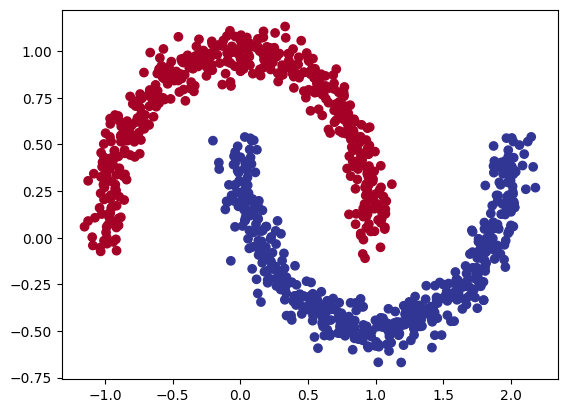

In [60]:
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu);

In [61]:
from sklearn.model_selection import train_test_split

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=RANDOM_SEED)

len(X_train),len(X_test),len(y_train),len(y_test)

(800, 200, 800, 200)

In [62]:
import pandas as pd

moon = pd.DataFrame({'X1':X[:,0],'X2':X[:,1],'label':y})
moon.label.value_counts()


label
1.0    500
0.0    500
Name: count, dtype: int64

Build a model by subclassing nn.Module that incorporates non-linear activation functions and is capable of fitting the data created

In [63]:
from torch import nn

class ModelMoon(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=2, out_features=10),
            nn.ReLU(),  
            nn.Linear(in_features=10, out_features=10),
            nn.ReLU(),  
            nn.Linear(in_features=10, out_features=1)
        )
    
    def forward(self, x):
        return self.linear_layer_stack(x)

In [64]:
model_0 = ModelMoon().to(device)
model_0

ModelMoon(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=1, bias=True)
  )
)

In [65]:
loss_fn = nn.BCEWithLogitsLoss()
optim = torch.optim.SGD(model_0.parameters(),lr=0.01)

In [66]:
X_train,y_train = X_train.to(device),y_train.to(device)
X_test,y_test = X_test.to(device),y_test.to(device)

In [67]:

# logits (raw outputs of model)
print("Logits:")
print(model_0(X_train.to(device)[:10]).squeeze())

# Prediction probabilities
print("Pred probs:")
print(torch.sigmoid(model_0(X_train.to(device)[:10]).squeeze()))

# Prediction probabilities
print("Pred labels:")
print(torch.round(torch.sigmoid(model_0(X_train.to(device)[:10]).squeeze())))

Logits:
tensor([0.0019, 0.0094, 0.0161, 0.0185, 0.0284, 0.0192, 0.0291, 0.0196, 0.0258,
        0.0079], device='cuda:0', grad_fn=<SqueezeBackward0>)
Pred probs:
tensor([0.5005, 0.5024, 0.5040, 0.5046, 0.5071, 0.5048, 0.5073, 0.5049, 0.5065,
        0.5020], device='cuda:0', grad_fn=<SigmoidBackward0>)
Pred labels:
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], device='cuda:0',
       grad_fn=<RoundBackward0>)


In [68]:
def accuracy(y_true,y_pred):
    check = torch.eq(y_true,y_pred).sum().item()
    return (check / len(y_pred))*100

In [69]:
torch.manual_seed(RANDOM_SEED)
epochs = 20000

for epoch in range(epochs):
    model_0.train()

    y_logits = model_0(X_train).squeeze()
    y_preds = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits, y_train)  # FIXED
    optim.zero_grad()
    acc = accuracy(y_preds, y_train)  # FIXED
    loss.backward()
    optim.step()

    model_0.eval()
    with torch.inference_mode():
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy(test_pred, y_test)  # FIXED
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.2f} Acc: {acc:.2f} | Test loss: {test_loss:.2f} Test acc: {test_acc:.2f}")

Epoch: 0 | Loss: 0.70 Acc: 37.38 | Test loss: 0.70 Test acc: 39.00
Epoch: 100 | Loss: 0.68 Acc: 76.38 | Test loss: 0.68 Test acc: 71.50
Epoch: 200 | Loss: 0.67 Acc: 78.88 | Test loss: 0.67 Test acc: 76.00
Epoch: 300 | Loss: 0.65 Acc: 77.88 | Test loss: 0.65 Test acc: 73.00
Epoch: 400 | Loss: 0.63 Acc: 76.00 | Test loss: 0.63 Test acc: 69.00
Epoch: 500 | Loss: 0.59 Acc: 75.25 | Test loss: 0.60 Test acc: 70.00
Epoch: 600 | Loss: 0.55 Acc: 76.00 | Test loss: 0.56 Test acc: 72.50
Epoch: 700 | Loss: 0.51 Acc: 77.00 | Test loss: 0.52 Test acc: 74.50
Epoch: 800 | Loss: 0.46 Acc: 78.12 | Test loss: 0.48 Test acc: 75.50
Epoch: 900 | Loss: 0.42 Acc: 79.75 | Test loss: 0.44 Test acc: 76.00
Epoch: 1000 | Loss: 0.39 Acc: 81.75 | Test loss: 0.40 Test acc: 76.00
Epoch: 1100 | Loss: 0.36 Acc: 83.62 | Test loss: 0.38 Test acc: 78.50
Epoch: 1200 | Loss: 0.34 Acc: 84.25 | Test loss: 0.35 Test acc: 80.50
Epoch: 1300 | Loss: 0.32 Acc: 84.62 | Test loss: 0.33 Test acc: 81.50
Epoch: 1400 | Loss: 0.31 Acc: 85

In [70]:
import numpy as np

# TK - this could go in the helper_functions.py and be explained there
def plot_decision_boundary(model, X, y):
  
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Source - https://madewithml.com/courses/foundations/neural-networks/ 
    # (with modifications)
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), 
                         np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # mutli-class
    else: 
        y_pred = torch.round(torch.sigmoid(y_logits)) # binary
    
    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

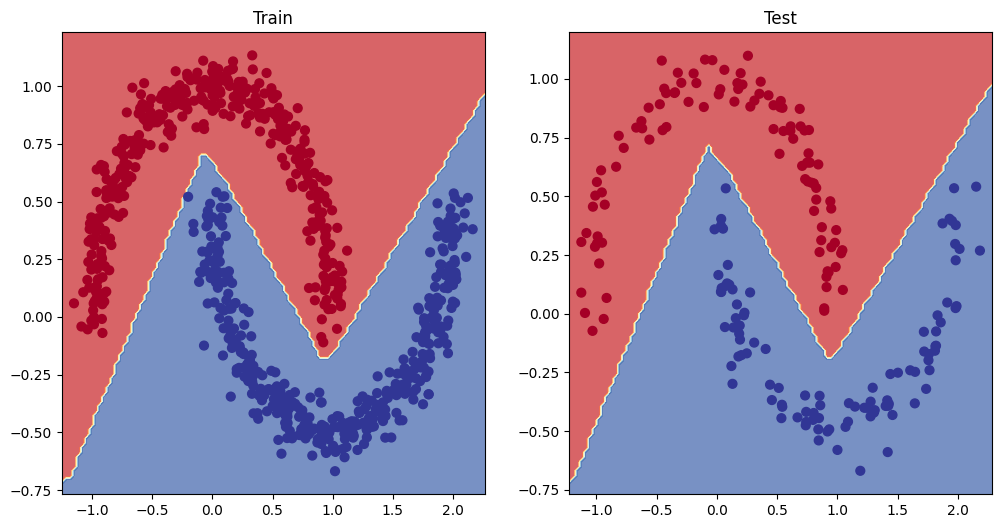

In [71]:

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)